In [92]:
import pydartdiags.obs_sequence.obs_sequence as obsq
import numpy as np
import sys
import kecd
import matplotlib.pyplot as plt
from scipy.stats import norm

from importlib import reload
reload(kecd)

<module 'kecd' from '/Users/santer/dart-nle/experiments/scripts/kecd.py'>

In [85]:
input_obs_seq_final = '../output/l63/run_control/filter0/output_chunks/obs_seq.final.control.'
curr_time = 1000
n_train = 1000

chunk_len_days = 0
chunk_len_secs = 18000
obs_sqs = []

for i in range(curr_time - n_train+1,curr_time+1):
    chunk = obsq.ObsSequence(input_obs_seq_final + '{}'.format(i))
    chunk.df['days'] += (i-1) * chunk_len_days
    chunk.df['seconds'] += (i-1) * chunk_len_secs
    chunk.df['time'] += np.timedelta64((i-1) * chunk_len_days, 'D')
    chunk.df['time'] += np.timedelta64((i-1) * chunk_len_secs, 's')
    obs_sqs.append(chunk)
    
obs_seq_train = obsq.ObsSequence.join(obs_sqs)


In [77]:
cols = ['posterior_ensemble_member_{}'.format(i) for i in range(1,41)]
np.random.seed(58)
obs_seq_train.df["random_posterior_draw"] = obs_seq_train.df[cols].to_numpy()[
    np.arange(len(obs_seq_train.df)),
    np.random.randint(0, len(cols), size=len(obs_seq_train.df))
]

y_train = obs_seq_train.df['observation'].values.reshape((len(obs_seq_train.df), -1)).T
x_train_t = obs_seq_train.df['truth'].values.reshape((len(obs_seq_train.df), -1)).T
x_train_p = obs_seq_train.df['random_posterior_draw'].values.reshape((len(obs_seq_train.df), -1)).T

In [88]:
pab, x_emb, y_emb, keeps = kecd.rkhs_likelihood(y_train.T, x_train_t.T, 50, 100, 0.0, 0.05, 1, 1)
Vx, Dx, a_train_x, bwx = x_emb
Vy, Dy, a_train_y, bwy = y_emb

<module 'numpy' from '/homes/metogra/hsanter/anaconda3/envs/dart-nle/lib/python3.10/site-packages/numpy/__init__.py'>
<module 'numpy' from '/homes/metogra/hsanter/anaconda3/envs/dart-nle/lib/python3.10/site-packages/numpy/__init__.py'>


Text(0.5, 1.0, 'Conditional Likelihood Estimates')

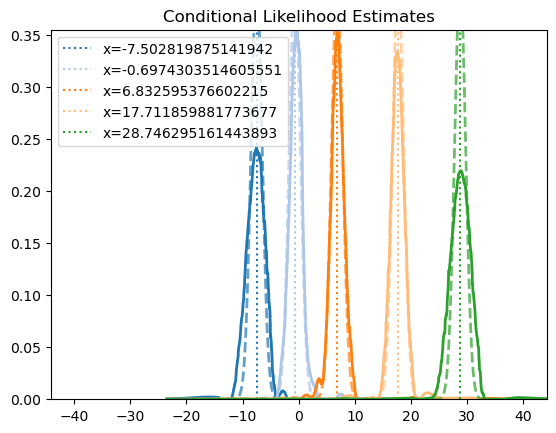

In [80]:
plot_states=True
ys = np.sort(y_train[0, :])
ind2 = np.argsort(y_train[0, :])
diff = np.diff(ys)

fig, ax = plt.subplots()
cmap = plt.get_cmap('tab20')

htp = []

pab_sample_states = -999

if pab_sample_states == -999:
      states = np.quantile(x_train_t, [0.1, 0.25, 0.5, 0.75, 0.9])
else:
      states = pab_sample_states

for ind, j in enumerate(states):
      dum = np.abs(j - x_train_t[0, :])
      ind1 = np.argsort(dum)[0]

      h = pab[ind2, ind1]

      # Normalize for plotting
      normalization = np.sum((h[:-1] + h[1:]) * diff / 2)
      h_norm = h / normalization
      htp.append(h_norm)

      # Plotting
      ax.plot(ys, h_norm, linewidth=2, color=cmap(ind))
      ax.plot(ys, norm.pdf(ys, loc=j), linewidth=2, color=cmap(ind), linestyle='dashed', alpha=0.7)
      if plot_states:
            ax.axvline(x=j, color=cmap(ind), linestyle='dotted', label=f'x={j}')

bound = max(np.abs(np.min(x_train_t)), np.abs(np.max(x_train_t)))
ax.set_xlim([-bound, bound])
ax.set_ylim([0, np.max(htp)])
ax.legend()

ax.set_title(f'Conditional Likelihood Estimates')

In [86]:
next_batch = obsq.ObsSequence('../output/l63/run_control/filter0/output_chunks/obs_seq.final.control.1001')

In [115]:
next_batch.df
new_obs = next_batch.df['observation'].values.reshape((len(next_batch.df), -1)).T
y_train = obs_seq_train.df['observation'].values.reshape((len(obs_seq_train.df), -1)).T

obs_emb = kecd.diff_map_ext_nystrom(new_obs.T, y_train.T, Vy, Dy, a_train_y, bwy, 100, 1)

LinAlgError: Last 2 dimensions of the array must be square

In [112]:
np.asarray(a_train_y)

array([[0.09455184, 0.09410381, 0.09991943, ..., 0.09809605, 0.09904371,
        0.09947294]], shape=(1, 3000))